# HW 16 - Animation
ULAB - Physics and Astronomy Division \
Due **Sunday, March 16th, 2025 at 11:59pm** on Gradescope

**Make sure to work on this notebook in DataHub!**

# 1) Recap of lecture
**Copy and paste** your code from lecture for the neural network with the **default** settings (i.e. before we improved the model). Make sure to also import the `data.py` file. 

In [1]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu
  Using cached https://download.pytorch.org/whl/cpu/torch-2.6.0%2Bcpu-cp311-cp311-linux_x86_64.whl.metadata (26 kB)
  Using cached https://download.pytorch.org/whl/cpu/torchvision-0.21.0%2Bcpu-cp311-cp311-linux_x86_64.whl.metadata (6.1 kB)
  Using cached https://download.pytorch.org/whl/cpu/torchaudio-2.6.0%2Bcpu-cp311-cp311-linux_x86_64.whl.metadata (6.6 kB)
  Using cached https://download.pytorch.org/whl/filelock-3.13.1-py3-none-any.whl.metadata (2.8 kB)
  Using cached https://download.pytorch.org/whl/fsspec-2024.6.1-py3-none-any.whl.metadata (11 kB)
  Using cached https://download.pytorch.org/whl/sympy-1.13.1-py3-none-any.whl (6.2 MB)
Using cached https://download.pytorch.org/whl/cpu/torch-2.6.0%2Bcpu-cp311-cp311-linux_x86_64.whl (178.7 MB)
Using cached https://download.pytorch.org/whl/cpu/torchvision-0.21.0%2Bcpu-cp311-cp311-linux_x86_64.whl (1.8 MB)
Using cached https://download.pytorch.org/whl/cpu/torchaudio-2.6.0%2Bcpu-cp3

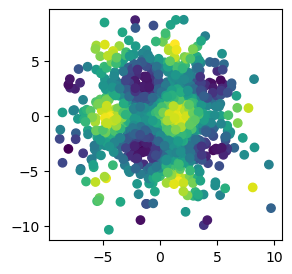

Iteration 0, Loss: 0.9950938820838928
Iteration 100, Loss: 0.9229540228843689
Iteration 200, Loss: 0.8295069336891174
Iteration 300, Loss: 0.691621720790863
Iteration 400, Loss: 0.5596290826797485
Iteration 500, Loss: 0.4563034772872925
Iteration 600, Loss: 0.38139092922210693
Iteration 700, Loss: 0.3249049484729767
Iteration 800, Loss: 0.2771148085594177
Iteration 900, Loss: 0.2391282469034195


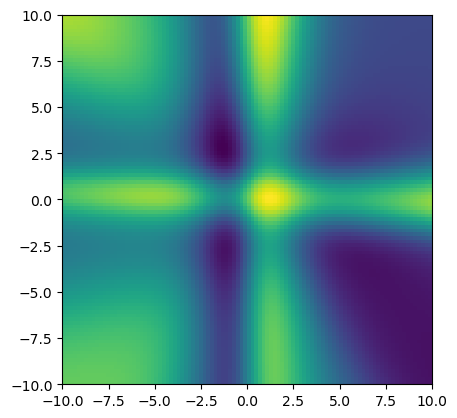

In [37]:
import data
import matplotlib.pyplot as plt

plt.figure(figsize=(3,3))
plt.scatter(data.x_values, data.y_values, c=data.color_values)
plt.show()

import torch
model = torch.nn.Sequential(
    torch.nn.Linear(2, 50),
    torch.nn.Sigmoid(),
    torch.nn.Linear(50, 1)
)

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
for t in range(1000):
    y_pred = model(data.x)      
    loss = loss_fn(y_pred, data.y)  
    optimizer.zero_grad()         
    loss.backward()                
    optimizer.step()                 

    if t % 100 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")
        
new_x = torch.linspace(-10, 10, 100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim=2)
output = model(grid).detach() 
output = output.squeeze(2).t()
plt.imshow(output, extent=(-10,10,-10,10))
plt.show()         

What is the difference between artificial intelligence, machine learning and deep learning?

Artificial intelligence is an umbrella term, anything that mimics human intelligence. Artificial intelligence are basically computers that are designed to do things that humans would; i.e., recognizing patterns, making decisions, learning from experience, and more. Machine learning is a subset of artificial intelligence. In machine learning, computers learn from data instead of being programmed explicitly, with more data resulting in better predictions. Deep leraning is a subset of machine learning, where the computer uses neural networks with various different layers in order to process data, especially ones that have complex patterns. It uses neurons which maps inputs to outputs. 

What is a neural network?

A neural network is what deep learning uses to process data. It has a bunch of different layers that have connected neurons. All of these layers work together in order to process data and recognize patterns. 

In lecture, we used `torch.nn.Linear(2, 50)`. What do the numbers `2` and `50` represent? 

The number 2 represents input size. Since there are 2 inputs, the x values and the y values, there are 2 inputs. The 50 represents how many layers our data is going to filter through, or the number of neurons. In this case, there will be 50 neurons.

What does the activation function do?

The activation function allows the neural network to do non linear math, allowing the algorithm to learn even more complicated and complex data.

What is a loss function? Why do we need one?

A loss function tells us how wrong our model is, or, how far off the model's preditions are from the actual values. This measure of how wrong the model is, is then used by the optimizer in order to see how much it needs to change and what it can improve before rerunning the code. Without this loss function, the model would not know how much to change or what it needs to fix in order to get better. 

Why do we call `optimizer.zero_grad()` before calling `loss.backward()`?

We call optimizer.zero_grad() before calling loss.backward() since we need to clear out the gradients from the previous training step to stop them from adding up across many different backward() calls. If we don't call this before the backward call, we will get training that is incorrect.

# 2) Modifying the Neural Network
What line do you need to modify to use **30 neurons** instead of **50**? Don't change anything else. Give the original and then modified line. 

In [4]:
#original line
torch.nn.Linear(2, 50),
torch.nn.Linear(50, 1)

#modified line. 30 represents the number of neurons
torch.nn.Linear(2, 30),
torch.nn.Linear(30, 1)

(Linear(in_features=2, out_features=30, bias=True),)

With your default code above, run your model with **30 neurons**. Compare the loss functions from lecture to your modification on the **1000th** iteration. 

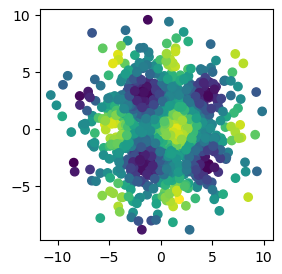

Iteration 0, Loss: 1.0728193521499634
Iteration 100, Loss: 1.0249286890029907
Iteration 200, Loss: 0.9223105907440186
Iteration 300, Loss: 0.7741315960884094
Iteration 400, Loss: 0.641559898853302
Iteration 500, Loss: 0.5372188091278076
Iteration 600, Loss: 0.44662049412727356
Iteration 700, Loss: 0.37271663546562195
Iteration 800, Loss: 0.31960374116897583
Iteration 900, Loss: 0.28342315554618835


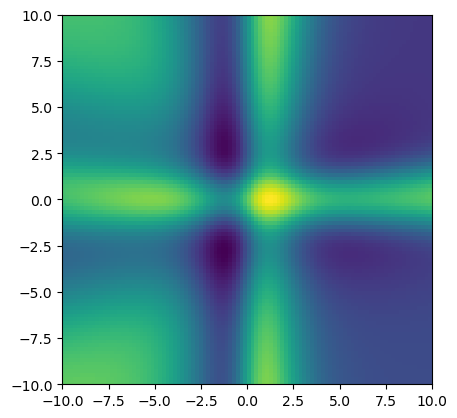

In [10]:
#as seen from the output below, the loss is actually higher than that of 50 neurons. 

import data
import matplotlib.pyplot as plt

plt.figure(figsize=(3,3))
plt.scatter(data.x_values, data.y_values, c=data.color_values)
plt.show()

#modified lines included to account for 30 neurons
import torch
model = torch.nn.Sequential(
    torch.nn.Linear(2, 30),
    torch.nn.Sigmoid(),
    torch.nn.Linear(30, 1)
)

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
for t in range(1000):
    y_pred = model(data.x)      
    loss = loss_fn(y_pred, data.y)  
    optimizer.zero_grad()         
    loss.backward()                
    optimizer.step()                 

    if t % 100 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")
        
new_x = torch.linspace(-10, 10, 100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim=2)
output = model(grid).detach() 
output = output.squeeze(2).t()
plt.imshow(output, extent=(-10,10,-10,10))
plt.show()         

Return to **50 neurons**. Change your activation function from `torch.nn.Sigmoid()` to `torch.nn.ReLU`. Compare the loss functions from lecture to your modification on the **1000th** iteration. 

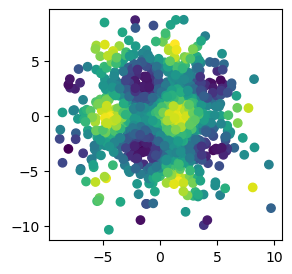

Iteration 0, Loss: 1.073124885559082
Iteration 100, Loss: 0.8054883480072021
Iteration 200, Loss: 0.6038857698440552
Iteration 300, Loss: 0.4549601972103119
Iteration 400, Loss: 0.3781047463417053
Iteration 500, Loss: 0.3363558351993561
Iteration 600, Loss: 0.31218820810317993
Iteration 700, Loss: 0.29756391048431396
Iteration 800, Loss: 0.285358726978302
Iteration 900, Loss: 0.272111177444458


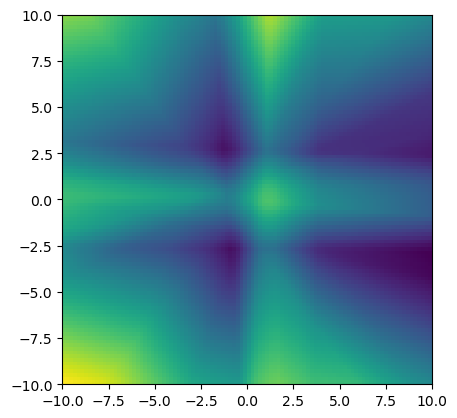

In [39]:
#the loss function is about the same as the one from lecture, but slightly higher. 

plt.figure(figsize=(3,3))
plt.scatter(data.x_values, data.y_values, c=data.color_values)
plt.show()

#here we switched from Sigmoid to ReLU
model = torch.nn.Sequential(
    torch.nn.Linear(2, 50),
    torch.nn.ReLU(),
    torch.nn.Linear(50, 1)
)

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
for t in range(1000):
    y_pred = model(data.x)      
    loss = loss_fn(y_pred, data.y)  
    optimizer.zero_grad()         
    loss.backward()                
    optimizer.step()                 

    if t % 100 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")
        
new_x = torch.linspace(-10, 10, 100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim=2)
output = model(grid).detach() 
output = output.squeeze(2).t()
plt.imshow(output, extent=(-10,10,-10,10))
plt.show()         

Change your activation function from `torch.nn.Sigmoid()` to `torch.nn.Tanh`? Compare the loss functions from lecture to your modification on the **1000th** iteration. 

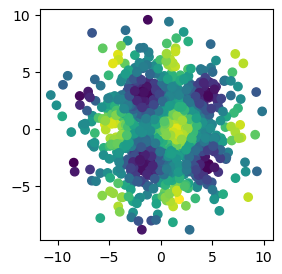

Iteration 0, Loss: 1.1205593347549438
Iteration 100, Loss: 0.8171724081039429
Iteration 200, Loss: 0.5046948790550232
Iteration 300, Loss: 0.3404562771320343
Iteration 400, Loss: 0.27429360151290894
Iteration 500, Loss: 0.23833438754081726
Iteration 600, Loss: 0.21286416053771973
Iteration 700, Loss: 0.19181662797927856
Iteration 800, Loss: 0.17350386083126068
Iteration 900, Loss: 0.1585197150707245


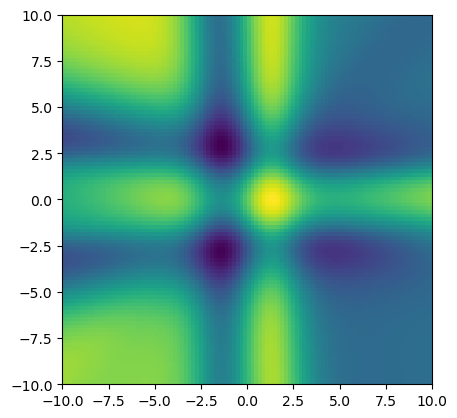

In [14]:
#the loss function is much lower using the activation function of .Tanh compared to .Sigmoid. It is almost twice as small.

plt.figure(figsize=(3,3))
plt.scatter(data.x_values, data.y_values, c=data.color_values)
plt.show()

#model changed to have the new activation function, Tanh.
model = torch.nn.Sequential(
    torch.nn.Linear(2, 50),
    torch.nn.Tanh(),
    torch.nn.Linear(50, 1)
)

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
for t in range(1000):
    y_pred = model(data.x)      
    loss = loss_fn(y_pred, data.y)  
    optimizer.zero_grad()         
    loss.backward()                
    optimizer.step()                 

    if t % 100 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")
        
new_x = torch.linspace(-10, 10, 100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim=2)
output = model(grid).detach() 
output = output.squeeze(2).t()
plt.imshow(output, extent=(-10,10,-10,10))
plt.show()         

What is the difference between `torch.nn.Sigmoid()`, `torch.nn.ReLU` and `torch.nn.Tanh`? 

While all of these are activation functions, they each have subtlties in the way they are used. Sigmoid condenses the output to numbers between 0 and 1, while ReLU keeps all positive numbers by turning negatives into 0. ReLU works well for hidden layers. Tanh is similar to Sigmoid but it condenses the output to numbers between -1 and 1, which lets the model have both positive and negative numbers, making it better for our case.

Return to `torch.nn.Sigmoid()`. Change your learning rate from `1e-3` to `1e-2` in your optimizer. Compare the loss functions from lecture to your modification on the **1000th** iteration. 

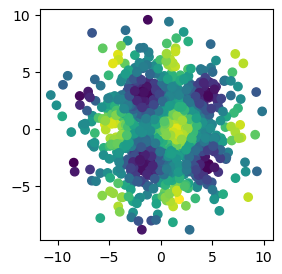

Iteration 0, Loss: 1.0726972818374634
Iteration 100, Loss: 0.37294065952301025
Iteration 200, Loss: 0.24554184079170227
Iteration 300, Loss: 0.18810899555683136
Iteration 400, Loss: 0.16365432739257812
Iteration 500, Loss: 0.15069268643856049
Iteration 600, Loss: 0.1395525187253952
Iteration 700, Loss: 0.13483676314353943
Iteration 800, Loss: 0.10794428735971451
Iteration 900, Loss: 0.09394773840904236


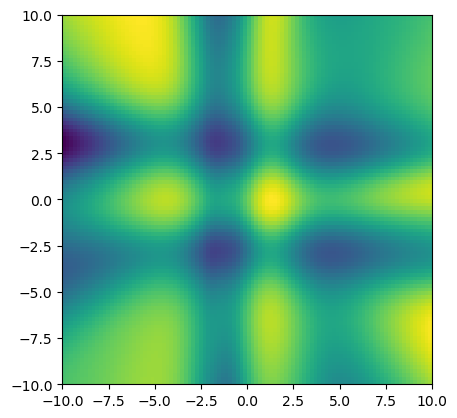

In [18]:
#by changing the learning rate from 1e-3 to 1e-2, the loss function jumps down to the lowest it's been out of any of the previous trials. It is at 0.03 in current run.

plt.figure(figsize=(3,3))
plt.scatter(data.x_values, data.y_values, c=data.color_values)
plt.show()

model = torch.nn.Sequential(
    torch.nn.Linear(2, 50),
    torch.nn.Sigmoid(),
    torch.nn.Linear(50, 1)
)

loss_fn = torch.nn.MSELoss()

#changed lr from 1e-3 to 1e-2.
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
for t in range(1000):
    y_pred = model(data.x)      
    loss = loss_fn(y_pred, data.y)  
    optimizer.zero_grad()         
    loss.backward()                
    optimizer.step()                 

    if t % 100 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")
        
new_x = torch.linspace(-10, 10, 100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim=2)
output = model(grid).detach() 
output = output.squeeze(2).t()
plt.imshow(output, extent=(-10,10,-10,10))
plt.show()         

Modify your model to have **two hidden layers** instead of one. Give that code here.

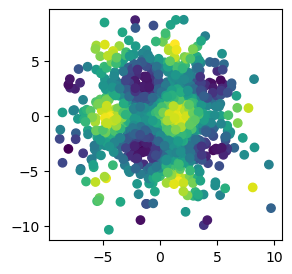

Iteration 0, Loss: 1.0408464670181274
Iteration 100, Loss: 0.32870611548423767
Iteration 200, Loss: 0.2227390855550766
Iteration 300, Loss: 0.18552543222904205
Iteration 400, Loss: 0.14824850857257843
Iteration 500, Loss: 0.1231212466955185
Iteration 600, Loss: 0.10932159423828125
Iteration 700, Loss: 0.09297174215316772
Iteration 800, Loss: 0.0780259519815445
Iteration 900, Loss: 0.07157445698976517


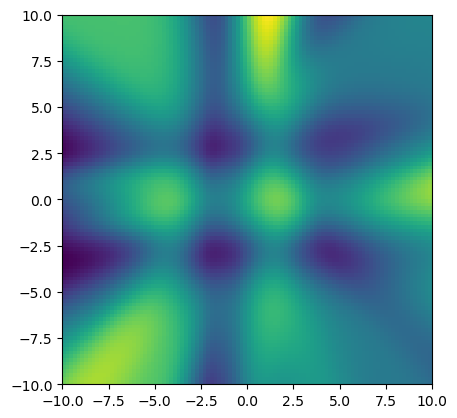

In [3]:
plt.figure(figsize=(3,3))
plt.scatter(data.x_values, data.y_values, c=data.color_values)
plt.show()

#model is changed to incorporate another layer. 
model = torch.nn.Sequential(
    torch.nn.Linear(2, 50),    #first hidden layer
    torch.nn.Sigmoid(),
    torch.nn.Linear(50, 50),    #second hidden layer
    torch.nn.Sigmoid(),
    torch.nn.Linear(50, 1)
)

loss_fn = torch.nn.MSELoss()

#changed lr from 1e-3 to 1e-2.
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
for t in range(1000):
    y_pred = model(data.x)      
    loss = loss_fn(y_pred, data.y)  
    optimizer.zero_grad()         
    loss.backward()                
    optimizer.step()                 

    if t % 100 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")
        
new_x = torch.linspace(-10, 10, 100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim=2)
output = model(grid).detach() 
output = output.squeeze(2).t()
plt.imshow(output, extent=(-10,10,-10,10))
plt.show()         

# 3) More Advanced
Create a new file called `new_data.py`, make a new "hidden" function and add noise/ obscure the data (e.g. like what is done in `data.py` from lecture). Import that file here.

In [45]:
#importing the new hidden function data
import new_data

Define a new model and train it **poorly** in the cell below.

Iteration 0, Loss: 1.257912516593933
Iteration 2, Loss: 1.2806172370910645
Iteration 4, Loss: 1.9731359481811523
Iteration 6, Loss: 1.1946377754211426
Iteration 8, Loss: 1.3454779386520386


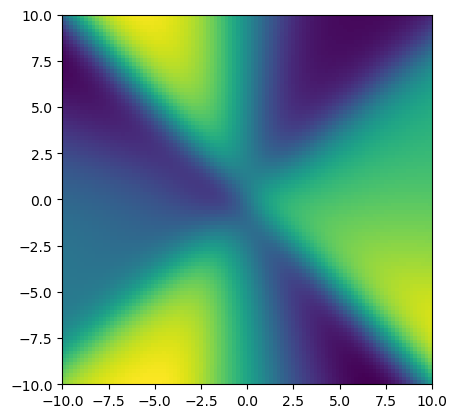

In [46]:
#importing necessary libraries
import torch
import matplotlib.pyplot as plt

#defining the model, one hidden layer, 30 neurons, using Sigmoid
poor_model = torch.nn.Sequential(
    torch.nn.Linear(2, 30),
    torch.nn.Sigmoid(),
    torch.nn.Linear(30, 1)
)

#loss function and optimizer. slow learning rate for the optimizer
poor_loss_fn = torch.nn.MSELoss()
poor_optimizer = torch.optim.Adam(poor_model.parameters(), lr=0.1)

#training. only 10 runthroughs is very low
for t in range(0, 10):
    y_pred = poor_model(new_data.x)      
    loss = poor_loss_fn(y_pred, new_data.y)  
    poor_optimizer.zero_grad()         
    loss.backward()                
    poor_optimizer.step()                 

    if t % 2 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")

#plotting
new_x = torch.linspace(-10, 10, 100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim=2)
output = poor_model(grid).detach() 
output = output.squeeze(2).t()
plt.imshow(output, extent=(-10,10,-10,10))
plt.show()         

Improve your model and train it **well** in the cell below. (You can add more neurons, iterations, etc).

Make foure subplots (two rows, two columns). 
- (TOP LEFT) Show what the "hidden pattern" is supposed to be.
- (TOP RIGHT) Show that your "data" is.
- (BOTTOM LEFT) Show your model's prediction when you trained it poorly.
- (BOTTOM RIGHT) Show your model's prediction when you trained it well.

Iteration 0, Loss: 1.1696103811264038
Iteration 200, Loss: 0.3883202373981476
Iteration 400, Loss: 0.22228267788887024
Iteration 600, Loss: 0.14559818804264069
Iteration 800, Loss: 0.09551937878131866
Iteration 1000, Loss: 0.07399862259626389
Iteration 1200, Loss: 0.06133986636996269
Iteration 1400, Loss: 0.05488885939121246
Iteration 1600, Loss: 0.05175374448299408
Iteration 1800, Loss: 0.0487050786614418
Iteration 2000, Loss: 0.047485802322626114
Iteration 2200, Loss: 0.044928912073373795
Iteration 2400, Loss: 0.04349471256136894
Iteration 2600, Loss: 0.042495083063840866
Iteration 2800, Loss: 0.04148352891206741
Iteration 3000, Loss: 0.040710825473070145
Iteration 3200, Loss: 0.03989169001579285
Iteration 3400, Loss: 0.03938840702176094
Iteration 3600, Loss: 0.038872573524713516
Iteration 3800, Loss: 0.038528118282556534
Iteration 4000, Loss: 0.03827666491270065
Iteration 4200, Loss: 0.037435971200466156
Iteration 4400, Loss: 0.03737109154462814
Iteration 4600, Loss: 0.0366780273616

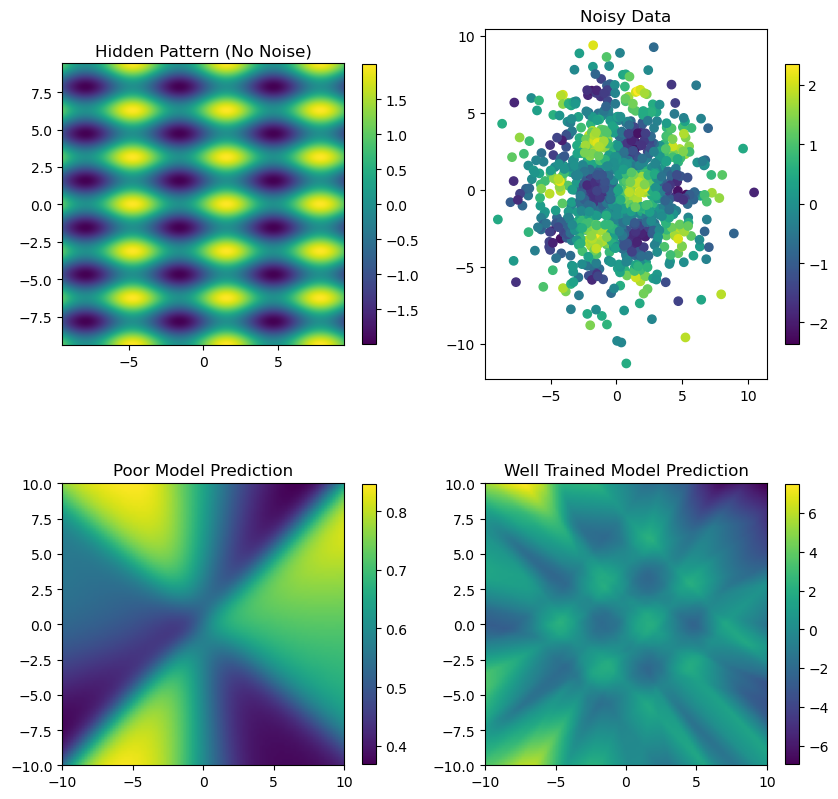

In [47]:
#importing necessary libraries
import torch
import matplotlib.pyplot as plt
import numpy as np

#hidden pattern
x_data = np.linspace(-3 * np.pi, 3 * np.pi, 1000)
y_data = np.linspace(-3 * np.pi, 3 * np.pi, 1000)
X, Y = np.meshgrid(x_data, y_data)
hidden_pattern = np.sin(X) + np.cos(2*Y)

#defining a good model. 2 hidden layers, 50 neurons, using ReLU
good_model = torch.nn.Sequential(
    torch.nn.Linear(2, 50),
    torch.nn.ReLU(),
    torch.nn.Linear(50, 50),
    torch.nn.ReLU(),
    torch.nn.Linear(50, 1)
)

#loss function and optimizer. the learning rate for the optimizer is very quick 
good_loss_fn = torch.nn.MSELoss()
good_optimizer = torch.optim.Adam(good_model.parameters(), lr=1e-3)

#training with 5000 runthroughs is very good
for t in range(0, 5000):
    y_pred = good_model(new_data.x)      
    loss = good_loss_fn(y_pred, new_data.y)  
    good_optimizer.zero_grad()         
    loss.backward()                
    good_optimizer.step()                 

    if t % 200 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")   

#creating the figure for the 4 subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10,10))

#figure for the hidden pattern
im1 = axes[0, 0].imshow(hidden_pattern, extent=(x_data.min(), x_data.max(), y_data.min(), y_data.max()), origin="lower")
axes[0, 0].set_title("Hidden Pattern (No Noise)")
plt.colorbar(im1, ax=axes[0, 0], shrink=0.8)

#figure for the data
scatter = axes[0, 1].scatter(new_data.x_values, new_data.y_values, c=new_data.color_values)
axes[0, 1].set_title("Noisy Data")
plt.colorbar(scatter, ax=axes[0, 1], shrink=0.8)

#figure for the prediction of the poor model
poor_new_x = torch.linspace(-10, 10, 100)
torch_grid = torch.stack(torch.meshgrid((poor_new_x, poor_new_x)), dim=2)
poor_output = poor_model(torch_grid).detach().squeeze(-1)
im2 = axes[1, 0].imshow(poor_output.t(), extent=(-10, 10, -10, 10), origin="lower")
axes[1, 0].set_title("Poor Model Prediction")
plt.colorbar(im2, ax=axes[1, 0], shrink=0.8)

#figure for the prediction of the well trained model
good_new_x = torch.linspace(-10, 10, 100)
good_torch_grid = torch.stack(torch.meshgrid((good_new_x, good_new_x)), dim=2)
good_output = good_model(good_torch_grid).detach().squeeze(-1)
im3 = axes[1, 1].imshow(good_output.t(), extent=(-10, 10, -10, 10), origin="lower")
axes[1, 1].set_title("Well Trained Model Prediction")
plt.colorbar(im3, ax=axes[1, 1], shrink=0.8)

plt.show()

# 4) Challenge
Find some data online and build a neural network around it. Make sure to also answer these questions:
- Where did you find your data? 
- How well does your model match your data?

In [ ]:
# Your code here

Once you are done, make sure to:
- Download this notebook and all releveant files (`new_data.py`, stuff from question 4, etc) from datahub.
- Move it to your **remote repository**.
- Upload to Gradescope!